In [1]:
from bidr_relight.main import relight_content_image
import numpy as np
import torch

from skimage.io import imread, imsave
import matplotlib.pyplot as plt
import os
from bidr_relight.isd_estimator.unet import ResNet50UNet

%load_ext autoreload
%autoreload 2


In [4]:
# ISD model
isd_model_path = "../weights/unet.pth"
isd_model = ResNet50UNet(
    in_channels=3,
    out_channels=3,
    pretrained=True,
    checkpoint=isd_model_path,
    se_block=True,
    dropout=0.0,
)

INFO: Initializing ResNet50UNet | in_channels=3, out_channels=3, pretrained=True, checkpoint=../weights/unet.pth, se_block=True
INFO: Loading ResNet50 weights from checkpoint: ../weights/unet.pth
INFO: ResNet50UNet Parameter Summary (Top-Level Modules):
INFO: --------------------------------------------------------------------------------
INFO: in_conv                   | Total: 9536                 | Trainable: 9,536
INFO: maxpool                   | Total: 0                    | Trainable: 0
INFO: enc1                      | Total: 215808               | Trainable: 215,808
INFO: enc2                      | Total: 1219584              | Trainable: 1,219,584
INFO: enc3                      | Total: 7098368              | Trainable: 7,098,368
INFO: enc4                      | Total: 14964736             | Trainable: 14,964,736
INFO: up4                       | Total: 16551456             | Trainable: 16,551,456
INFO: up3                       | Total: 2959120              | Trainable: 2

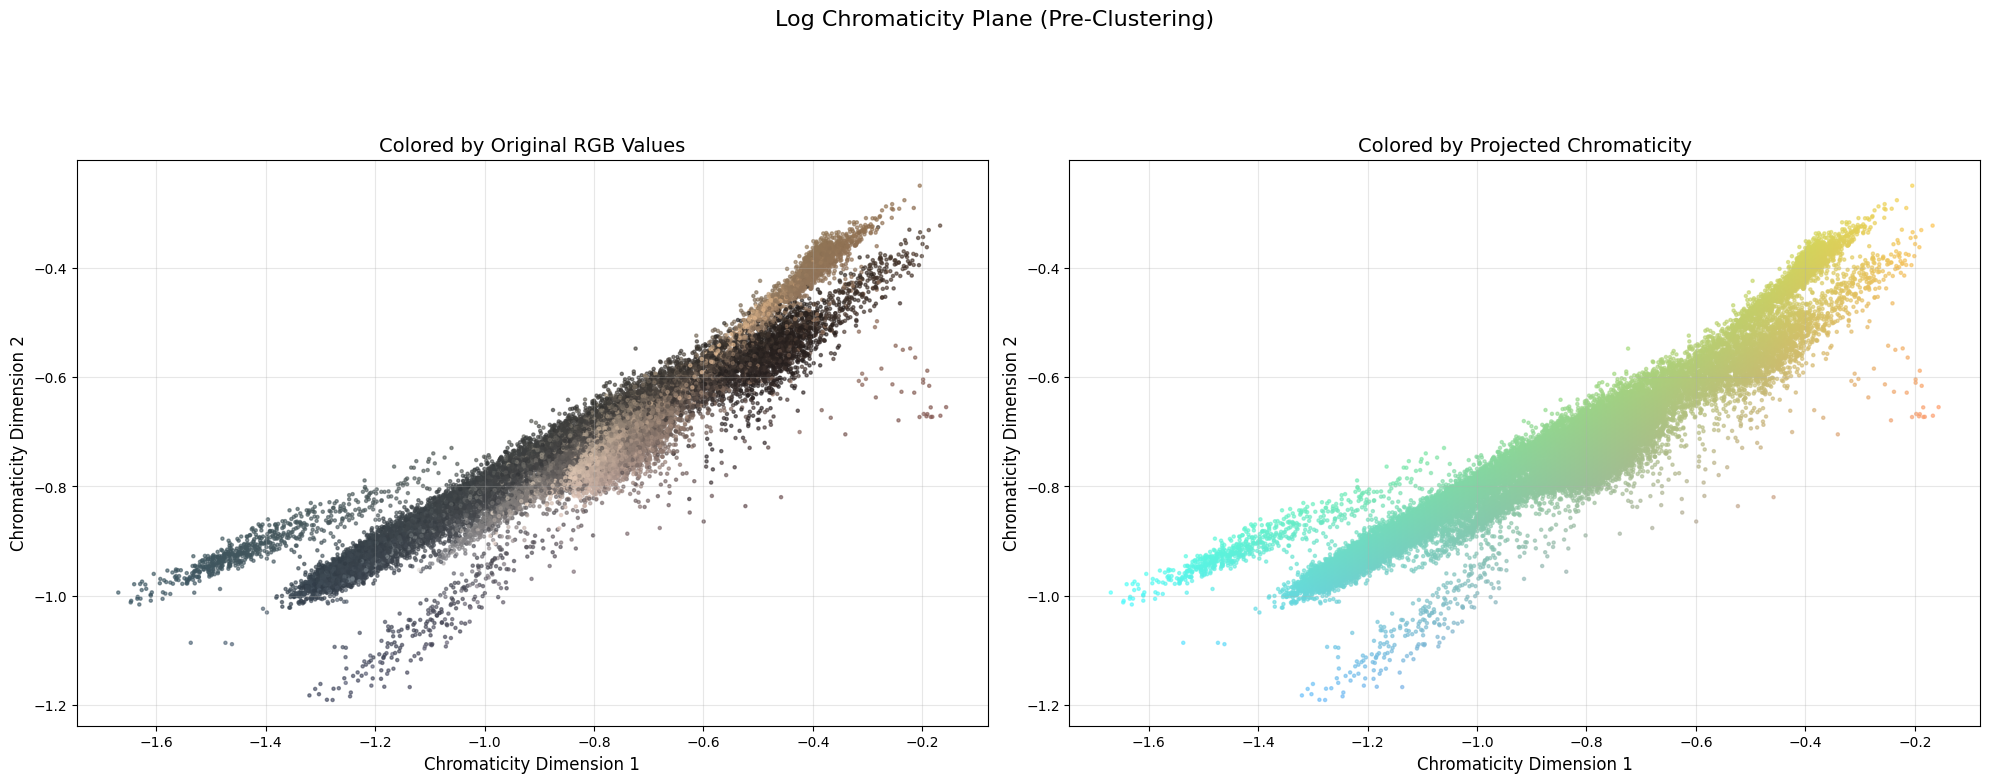

INFO: Greedy clustering: 13 clusters with radius=0.2


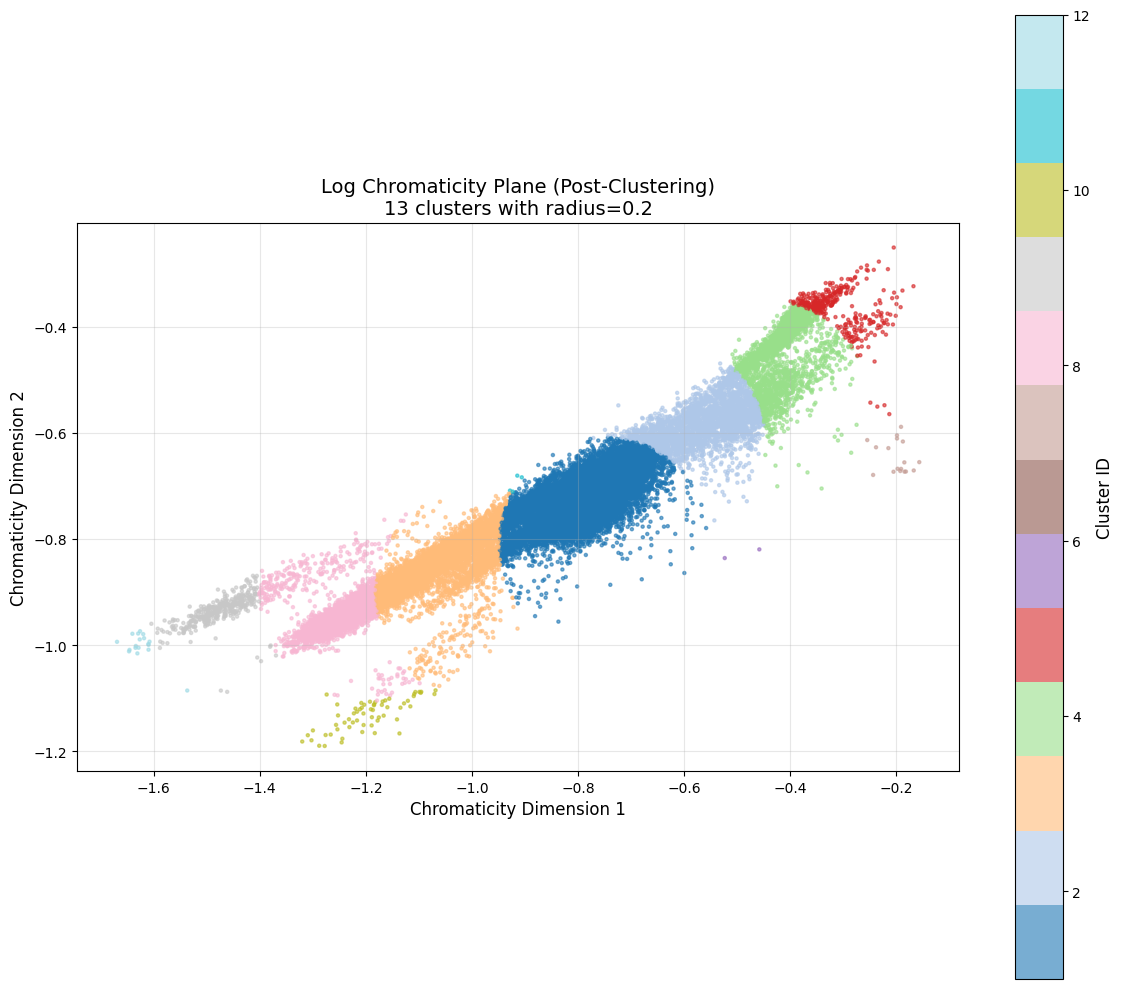

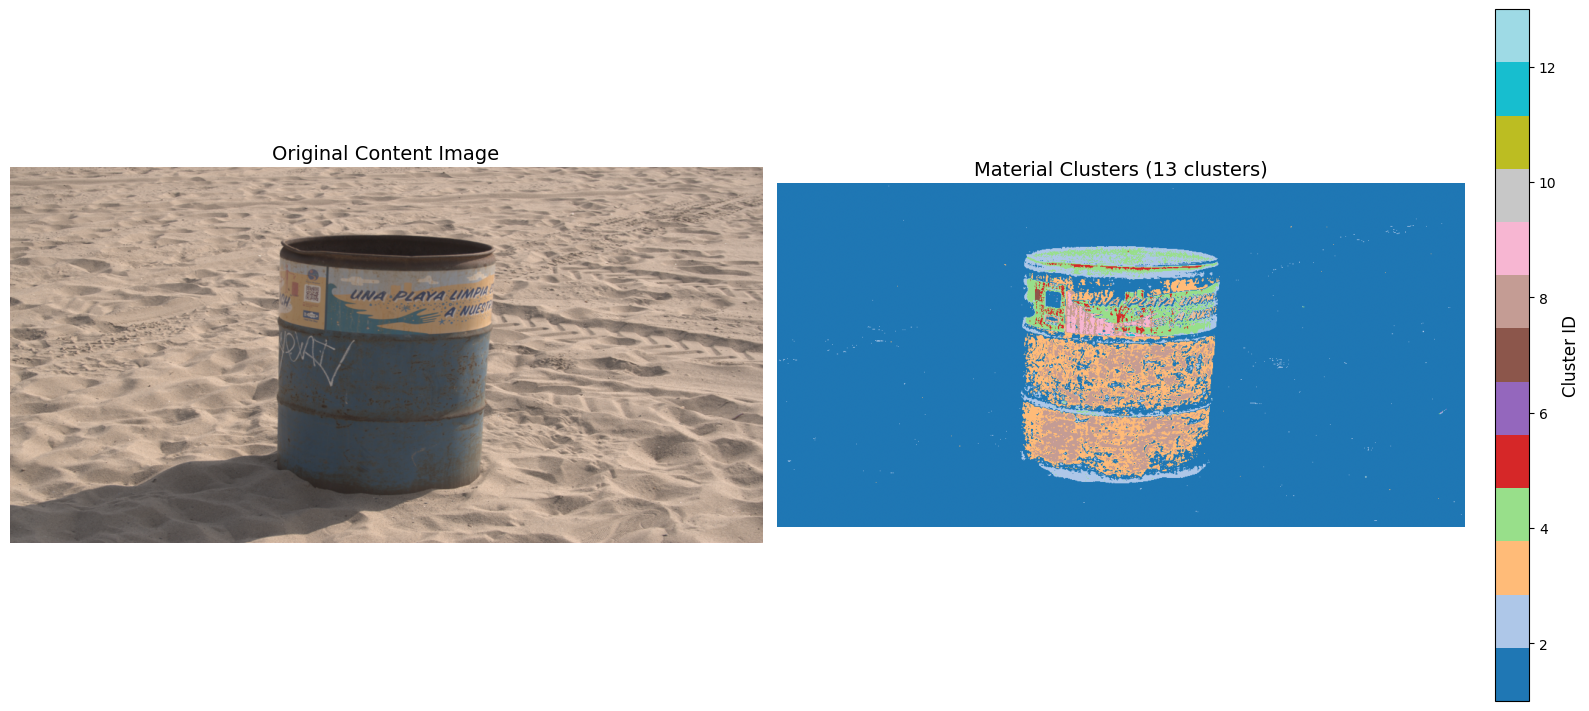

INFO: Estimated illumination vector norm 4.74545051967773
INFO: Estimated dark and bright points for 13 material clusters
INFO: Average Style ISD: [0.6510539  0.5817054  0.48759377]. Average Content ISD: [0.6280041 0.5844019 0.5138923]
INFO: Pivoted all pixels for each material cluster.


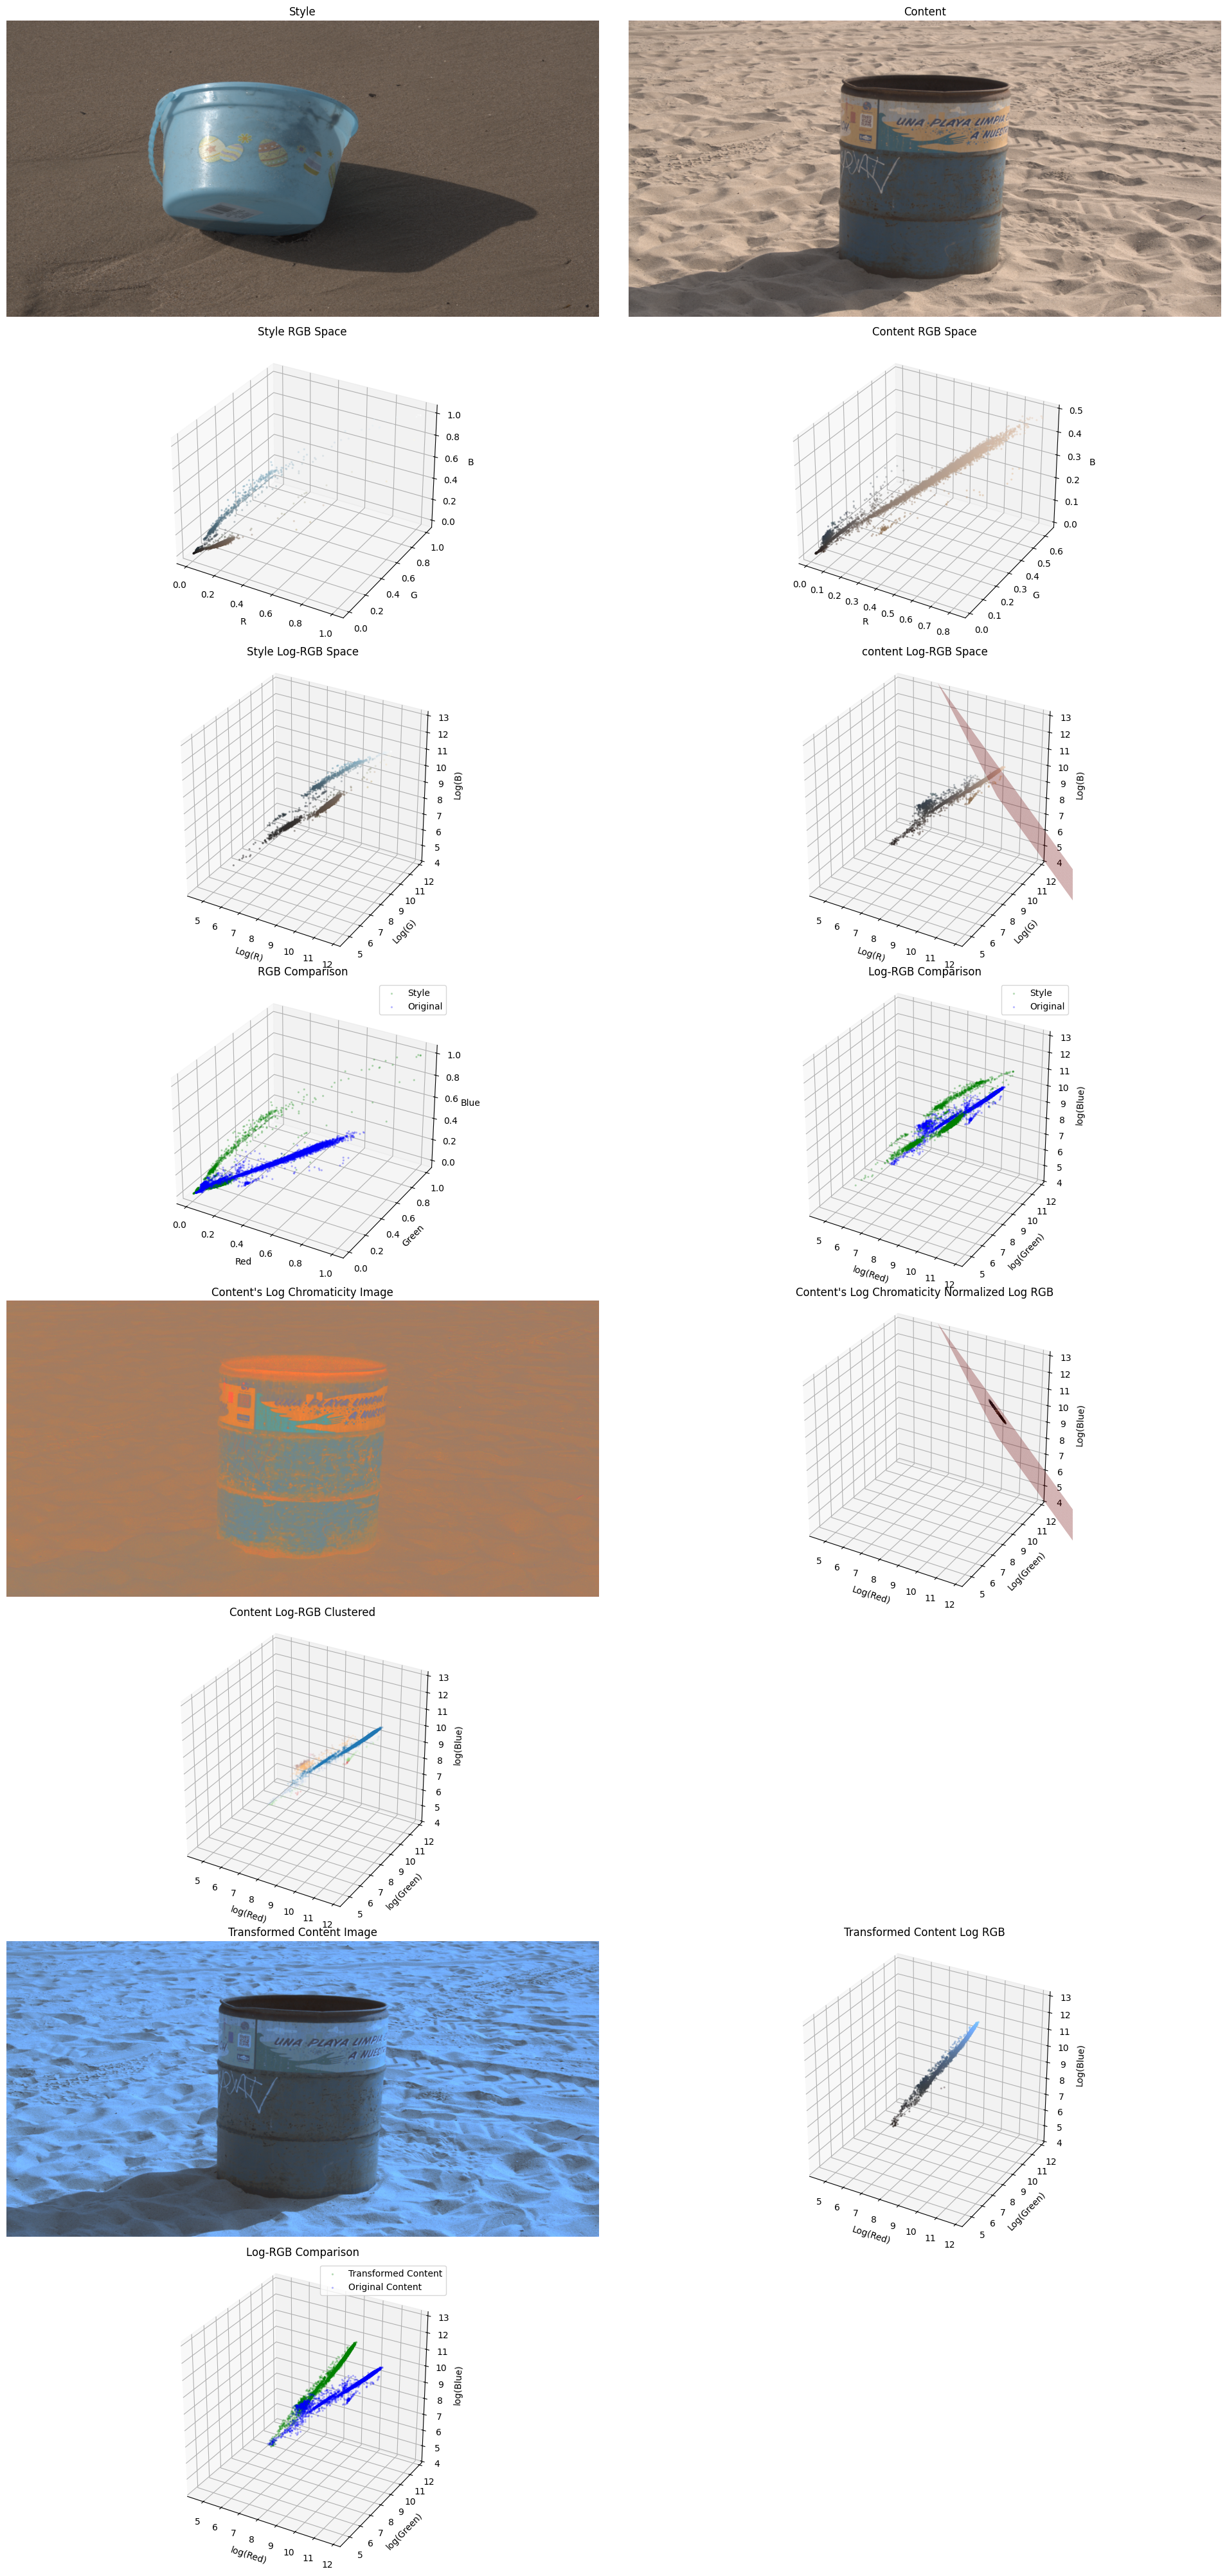

In [6]:
relight_content_image(
    # content_path="../data/compressed/bottle_sun.tiff",
    # style_path="../data/compressed/bottle_cloudy.tiff",
    content_path="../data/RAWAE/raw_maxwell_2023_05_26_ - 000212.tiff",
    style_path="../data/RAWAE/raw_maxwell_2023_05_26_ - 000225.tiff",
    # style_path="../data/RAWAE/raw_maxwell_2023_05_26_ - 000212.tiff",
    # content_path="../data/RAWAE/raw_maxwell_2023_05_26_ - 000225.tiff",
    # content_path="../data/RAWAE/raw_maxwell_2023_05_26_ - 001123.tiff",
    # style_path="../data/adh/IMG_8209.tiff",
    isd_model=isd_model,
    resize_scale=1 / 4,
    output_path="../data/target.png",
    clustering_method="greedy",  # greedy, kmeans
    view_isd=False,  # see log rgb perpendicular to isd. should look similar to log chroma plane from max.
    n_clusters=4,
    bin_radius=0.2,
    rot_percent=100.0,  # either change this or rot_angle, not both.
    rot_angle=np.deg2rad(-20.0),
    # log_transl=np.ones(3) * -1.0,
    length_scale=1.0,
    always_use_global_illum_norm=True,
)